# Análise Aprofundada — Sexo

CadÚnico amostra dez/2018

In [15]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
import os

warnings.filterwarnings("ignore")

BASE_DIR = os.path.abspath('')
DATA_DIR = os.path.join(BASE_DIR, "base_amostra_cad_201812")

PESSOA_FILE = os.path.join(DATA_DIR, "base_amostra_pessoa_201812.csv")
SEP         = ";"
ENCODING    = "latin-1"
AMOSTRA     = 200_000

COR_M = "#2563EB"   # masculino — azul
COR_F = "#DB2777"   # feminino  — rosa
CORES = [COR_M, COR_F]

# ── dicionários de decodificação ──────────────────────────────────────────────
SEXO_MAP = {1: "Masculino", 2: "Feminino"}

RACA_MAP = {1: "Branca", 2: "Preta", 3: "Amarela", 4: "Parda", 5: "Indígena"}

PARENTESCO_MAP = {
    1: "Responsável",
    2: "Cônjuge/companheiro",
    3: "Filho(a)",
    4: "Enteado(a)",
    5: "Neto(a)/bisneto(a)",
    6: "Pai/mãe",
    7: "Sogro(a)",
    8: "Irmão/irmã",
    9: "Genro/nora",
    10: "Outro parente",
    11: "Não parente",
}

ESC_MAP = {
    1: "Sem instrução",
    2: "Fund. incompleto",
    3: "Fund. completo",
    4: "Médio incompleto",
    5: "Médio completo",
    6: "Sup. incompleto",
    7: "Sup. completo",
    8: "Pós-grad.",
}

LER_MAP  = {1: "Sabe ler/escrever", 2: "Não sabe"}
DEF_MAP  = {1: "Com deficiência", 2: "Sem deficiência"}
TRAB_MAP = {1: "Trabalhou", 2: "Não trabalhou"}
FREQ_MAP = {1: "Frequenta", 2: "Não frequenta", 3: "Nunca frequentou"}

## CARGA

In [16]:
print("Carregando dados...")
df = pd.read_csv(PESSOA_FILE, sep=SEP, encoding=ENCODING,
                 nrows=AMOSTRA, low_memory=False)

df["sexo"]       = df["cod_sexo_pessoa"].map(SEXO_MAP)
df["faixa"]      = pd.cut(
    df["idade"],
    bins=[0, 4, 9, 14, 17, 24, 34, 44, 59, 79, 999],
    labels=["0-4","5-9","10-14","15-17","18-24","25-34","35-44","45-59","60-79","80+"],
    right=True
)
df["raca"]        = df["cod_raca_cor_pessoa"].map(RACA_MAP)
df["parentesco"]  = df["cod_parentesco_rf_pessoa"].map(PARENTESCO_MAP)
df["escolaridade"]= df["cod_curso_frequentou_pessoa_memb"].map(ESC_MAP)
df["sabe_ler"]    = df["cod_sabe_ler_escrever_memb"].map(LER_MAP)
df["deficiencia"] = df["cod_deficiencia_memb"].map(DEF_MAP)
df["trabalhou"]   = df["cod_trabalhou_memb"].map(TRAB_MAP)
df["freq_escola"] = df["ind_frequenta_escola_memb"].map(FREQ_MAP)

print(f"  {len(df):,} registros carregados\n")

Carregando dados...
  200,000 registros carregados



## 1. PROPORÇÃO GERAL + IDADE MÉDIA

=== 1. Proporção e estatísticas básicas ===
sexo
Feminino     56.8
Masculino    43.2

  Idade por sexo:
              count       mean        std  min   25%   50%   75%    max
sexo                                                                   
Feminino   113525.0  28.309703  19.987816  0.0  12.0  26.0  42.0  120.0
Masculino   86475.0  24.724718  20.718913  0.0   8.0  18.0  39.0  108.0


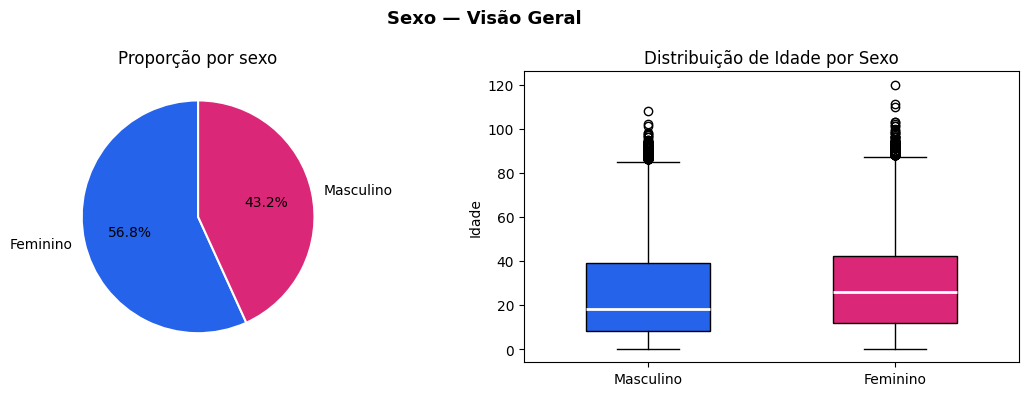

In [17]:
print("=== 1. Proporção e estatísticas básicas ===")
prop = df["sexo"].value_counts(normalize=True).mul(100).round(1)
print(prop.to_string())

idade_stats = df.groupby("sexo")["idade"].describe()
print(f"\n  Idade por sexo:\n{idade_stats.to_string()}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# pizza
axes[0].pie(prop.values, labels=prop.index, autopct="%1.1f%%",
            colors=CORES, startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[0].set_title("Proporção por sexo")

# boxplot idade
data_box = [df[df["sexo"] == s]["idade"].dropna() for s in ["Masculino", "Feminino"]]
bp = axes[1].boxplot(data_box, patch_artist=True, widths=0.5,
                     medianprops={"color": "white", "linewidth": 2})
for patch, cor in zip(bp["boxes"], CORES):
    patch.set_facecolor(cor)
axes[1].set_xticklabels(["Masculino", "Feminino"])
axes[1].set_ylabel("Idade")
axes[1].set_title("Distribuição de Idade por Sexo")

plt.suptitle("Sexo — Visão Geral", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 2. FAIXA ETÁRIA POR SEXO (barras agrupadas)


=== 2. Faixa etária por sexo ===


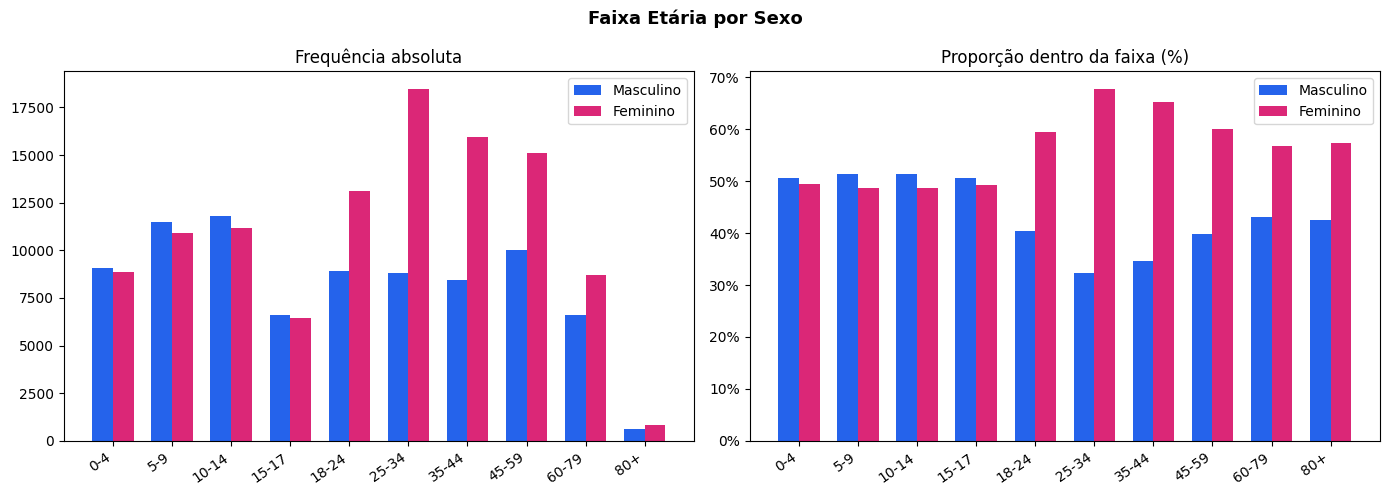

In [18]:
print("\n=== 2. Faixa etária por sexo ===")
tab_faixa = df.groupby(["faixa", "sexo"], observed=True).size().unstack(fill_value=0)
tab_pct   = tab_faixa.div(tab_faixa.sum(axis=1), axis=0).mul(100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(tab_faixa))
w = 0.35
for ax, data, titulo in [
    (axes[0], tab_faixa, "Frequência absoluta"),
    (axes[1], tab_pct,   "Proporção dentro da faixa (%)")
]:
    ax.bar(x - w/2, data["Masculino"], w, label="Masculino", color=COR_M)
    ax.bar(x + w/2, data["Feminino"],  w, label="Feminino",  color=COR_F)
    ax.set_xticks(x)
    ax.set_xticklabels(tab_faixa.index.tolist(), rotation=35, ha="right")
    ax.set_title(titulo)
    ax.legend()
    if "%" in titulo:
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))

plt.suptitle("Faixa Etária por Sexo", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 3. RAÇA/COR POR SEXO


=== 3. Raça/Cor por Sexo ===


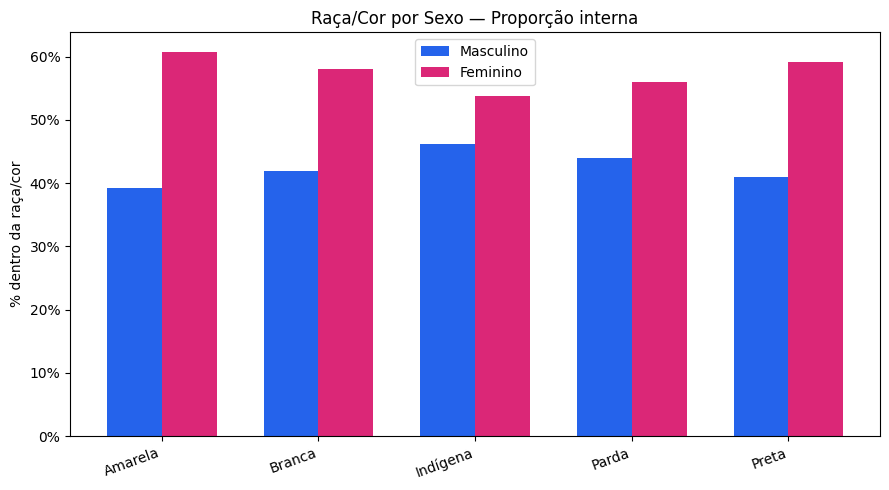

In [19]:
print("\n=== 3. Raça/Cor por Sexo ===")
tab_raca = df.groupby(["raca", "sexo"]).size().unstack(fill_value=0)
tab_raca_pct = tab_raca.div(tab_raca.sum(axis=1), axis=0).mul(100)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(tab_raca))
ax.bar(x - w/2, tab_raca_pct["Masculino"], w, label="Masculino", color=COR_M)
ax.bar(x + w/2, tab_raca_pct["Feminino"],  w, label="Feminino",  color=COR_F)
ax.set_xticks(x)
ax.set_xticklabels(tab_raca.index.tolist(), rotation=20, ha="right")
ax.set_ylabel("% dentro da raça/cor")
ax.set_title("Raça/Cor por Sexo — Proporção interna")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.legend()
plt.tight_layout()
plt.show()

## 4. PARENTESCO COM RESPONSÁVEL FAMILIAR


=== 4. Parentesco com RF por Sexo ===


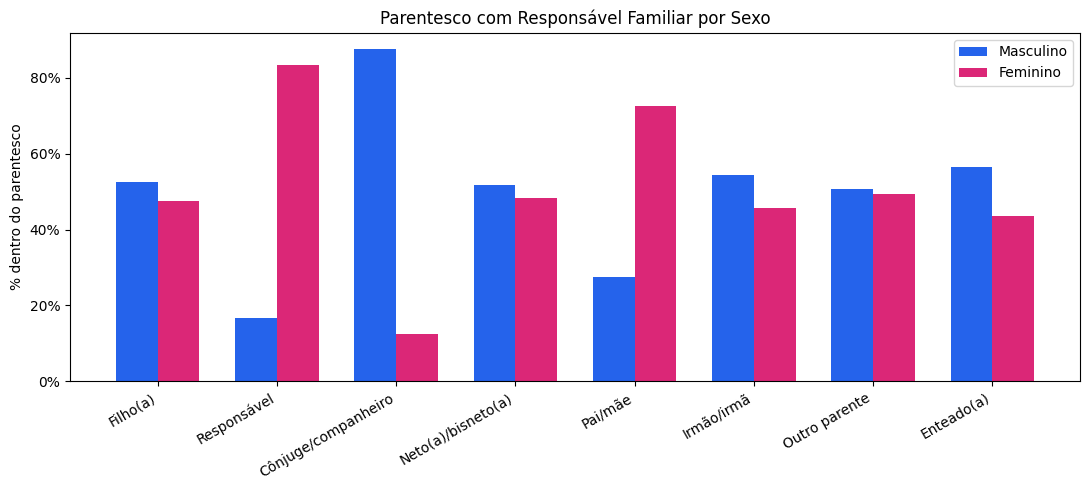


  Responsáveis familiares por sexo:
sexo
Feminino     83.3
Masculino    16.7


In [20]:
print("\n=== 4. Parentesco com RF por Sexo ===")
tab_par = (
    df.groupby(["parentesco", "sexo"])
    .size()
    .unstack(fill_value=0)
    .assign(total=lambda d: d.sum(axis=1))
    .sort_values("total", ascending=False)
    .drop(columns="total")
    .head(8)
)
tab_par_pct = tab_par.div(tab_par.sum(axis=1), axis=0).mul(100)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(tab_par_pct))
ax.bar(x - w/2, tab_par_pct["Masculino"], w, label="Masculino", color=COR_M)
ax.bar(x + w/2, tab_par_pct["Feminino"],  w, label="Feminino",  color=COR_F)
ax.set_xticks(x)
ax.set_xticklabels(tab_par_pct.index.tolist(), rotation=30, ha="right")
ax.set_ylabel("% dentro do parentesco")
ax.set_title("Parentesco com Responsável Familiar por Sexo")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.legend()
plt.tight_layout()
plt.show()

pct_rf = (
    df[df["parentesco"] == "Responsável"]["sexo"]
    .value_counts(normalize=True).mul(100).round(1)
)
print(f"\n  Responsáveis familiares por sexo:\n{pct_rf.to_string()}")

## 5. ESCOLARIDADE POR SEXO


=== 5. Escolaridade por Sexo ===


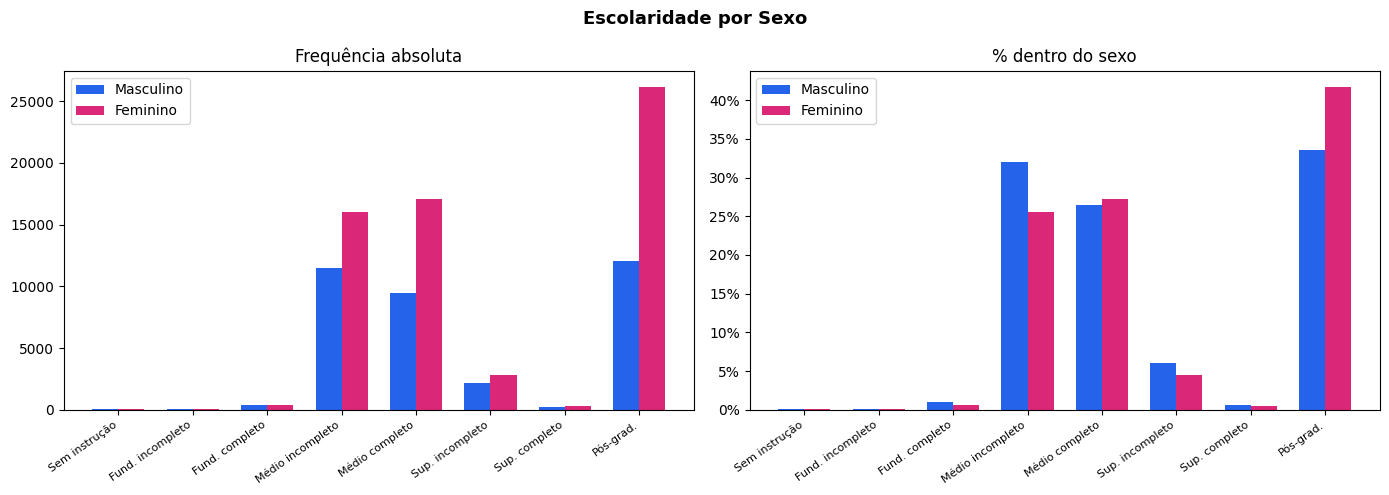

In [21]:
print("\n=== 5. Escolaridade por Sexo ===")
ordem_esc = list(ESC_MAP.values())
tab_esc = (
    df.groupby(["escolaridade", "sexo"])
    .size()
    .unstack(fill_value=0)
    .reindex(ordem_esc, fill_value=0)
)
tab_esc_pct = tab_esc.div(tab_esc.sum(axis=0), axis=1).mul(100)  # % dentro de cada sexo

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, data, titulo in [
    (axes[0], tab_esc,     "Frequência absoluta"),
    (axes[1], tab_esc_pct, "% dentro do sexo"),
]:
    x = np.arange(len(data))
    ax.bar(x - w/2, data["Masculino"], w, label="Masculino", color=COR_M)
    ax.bar(x + w/2, data["Feminino"],  w, label="Feminino",  color=COR_F)
    ax.set_xticks(x)
    ax.set_xticklabels(data.index.tolist(), rotation=35, ha="right", fontsize=8)
    ax.set_title(titulo)
    ax.legend()
    if "%" in titulo:
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))

plt.suptitle("Escolaridade por Sexo", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. ALFABETIZAÇÃO E FREQUÊNCIA ESCOLAR


=== 6. Alfabetização e Frequência Escolar ===


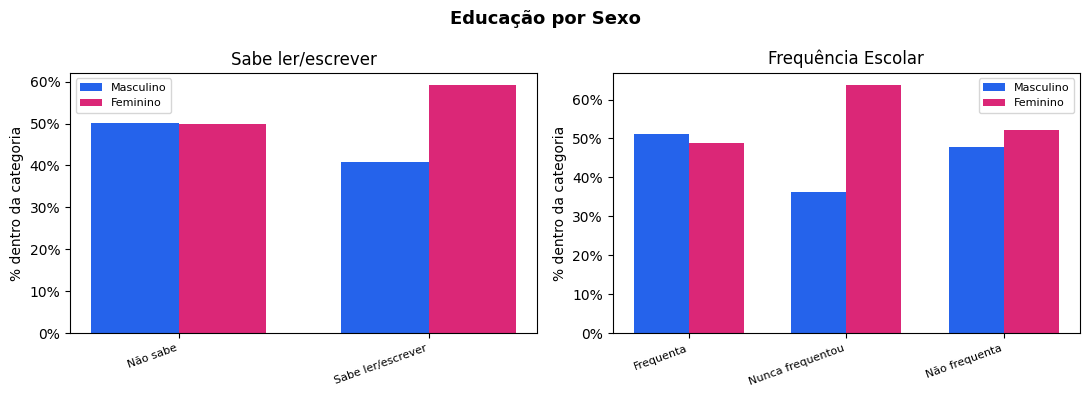

In [22]:
print("\n=== 6. Alfabetização e Frequência Escolar ===")
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, col, titulo in [
    (axes[0], "sabe_ler",    "Sabe ler/escrever"),
    (axes[1], "freq_escola", "Frequência Escolar"),
]:
    tab = df.groupby([col, "sexo"]).size().unstack(fill_value=0)
    tab_p = tab.div(tab.sum(axis=1), axis=0).mul(100)
    x = np.arange(len(tab_p))
    ax.bar(x - w/2, tab_p["Masculino"], w, label="Masculino", color=COR_M)
    ax.bar(x + w/2, tab_p["Feminino"],  w, label="Feminino",  color=COR_F)
    ax.set_xticks(x)
    ax.set_xticklabels(tab_p.index.tolist(), rotation=20, ha="right", fontsize=8)
    ax.set_title(titulo)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
    ax.set_ylabel("% dentro da categoria")
    ax.legend(fontsize=8)

plt.suptitle("Educação por Sexo", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. TRABALHO E RENDA

In [23]:
print("\n=== 7. Trabalho e Renda por Sexo ===")


=== 7. Trabalho e Renda por Sexo ===


### 7a. % que trabalhou

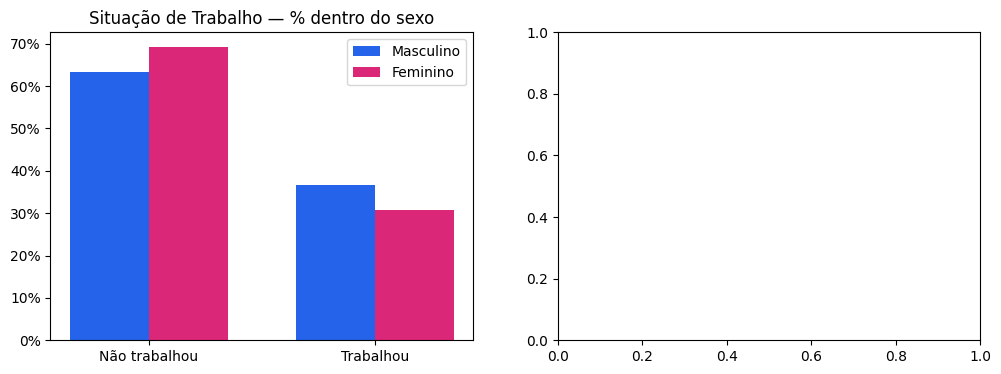

In [24]:
tab_trab = (
    df.groupby(["trabalhou", "sexo"])
    .size().unstack(fill_value=0)
    .pipe(lambda d: d.div(d.sum(axis=0), axis=1).mul(100))
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x = np.arange(len(tab_trab))
axes[0].bar(x - w/2, tab_trab["Masculino"], w, label="Masculino", color=COR_M)
axes[0].bar(x + w/2, tab_trab["Feminino"],  w, label="Feminino",  color=COR_F)
axes[0].set_xticks(x)
axes[0].set_xticklabels(tab_trab.index.tolist())
axes[0].set_title("Situação de Trabalho — % dentro do sexo")
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
axes[0].legend()

### 7b. Renda de emprego por sexo (boxplot — apenas positivos)

In [25]:
renda_m = df[(df["sexo"] == "Masculino") & (df["val_remuner_emprego_memb"] > 0)]["val_remuner_emprego_memb"]
renda_f = df[(df["sexo"] == "Feminino")  & (df["val_remuner_emprego_memb"] > 0)]["val_remuner_emprego_memb"]

bp = axes[1].boxplot(
    [renda_m, renda_f],
    patch_artist=True,
    widths=0.5,
    showfliers=False,
    medianprops={"color": "white", "linewidth": 2}
)
for patch, cor in zip(bp["boxes"], CORES):
    patch.set_facecolor(cor)
axes[1].set_xticklabels(["Masculino", "Feminino"])
axes[1].set_ylabel("R$")
axes[1].set_title("Renda de Emprego por Sexo (sem outliers)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}"))

plt.suptitle("Trabalho e Renda por Sexo", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\n  Renda média de emprego — Masculino: R$ {renda_m.mean():,.2f}")
print(f"  Renda média de emprego — Feminino:  R$ {renda_f.mean():,.2f}")
print(f"  Gap salarial (M-F): R$ {renda_m.mean() - renda_f.mean():,.2f}  ({(renda_m.mean()/renda_f.mean()-1)*100:.1f}%)")

<Figure size 640x480 with 0 Axes>


  Renda média de emprego — Masculino: R$ 578.13
  Renda média de emprego — Feminino:  R$ 472.77
  Gap salarial (M-F): R$ 105.36  (22.3%)


## 8. DEFICIÊNCIA POR SEXO


=== 8. Deficiência por Sexo ===


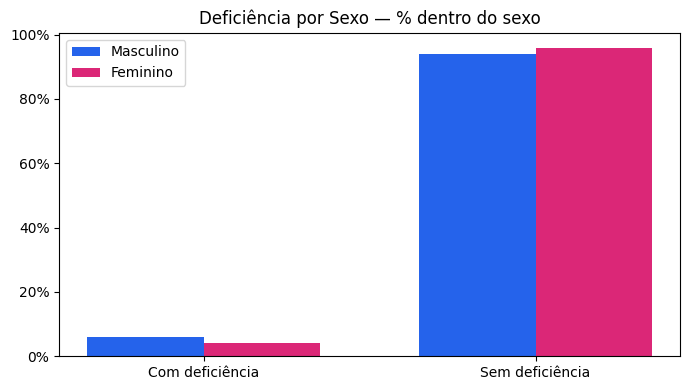

In [26]:
print("\n=== 8. Deficiência por Sexo ===")
tab_def = (
    df.groupby(["deficiencia", "sexo"])
    .size().unstack(fill_value=0)
    .pipe(lambda d: d.div(d.sum(axis=0), axis=1).mul(100))
)

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(tab_def))
ax.bar(x - w/2, tab_def["Masculino"], w, label="Masculino", color=COR_M)
ax.bar(x + w/2, tab_def["Feminino"],  w, label="Feminino",  color=COR_F)
ax.set_xticks(x)
ax.set_xticklabels(tab_def.index.tolist())
ax.set_title("Deficiência por Sexo — % dentro do sexo")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.legend()
plt.tight_layout()
plt.show()

## 9. HEATMAP — SEXO × FAIXA × RAÇA (contagem normalizada)


=== 9. Heatmap Faixa Etária × Raça por Sexo ===


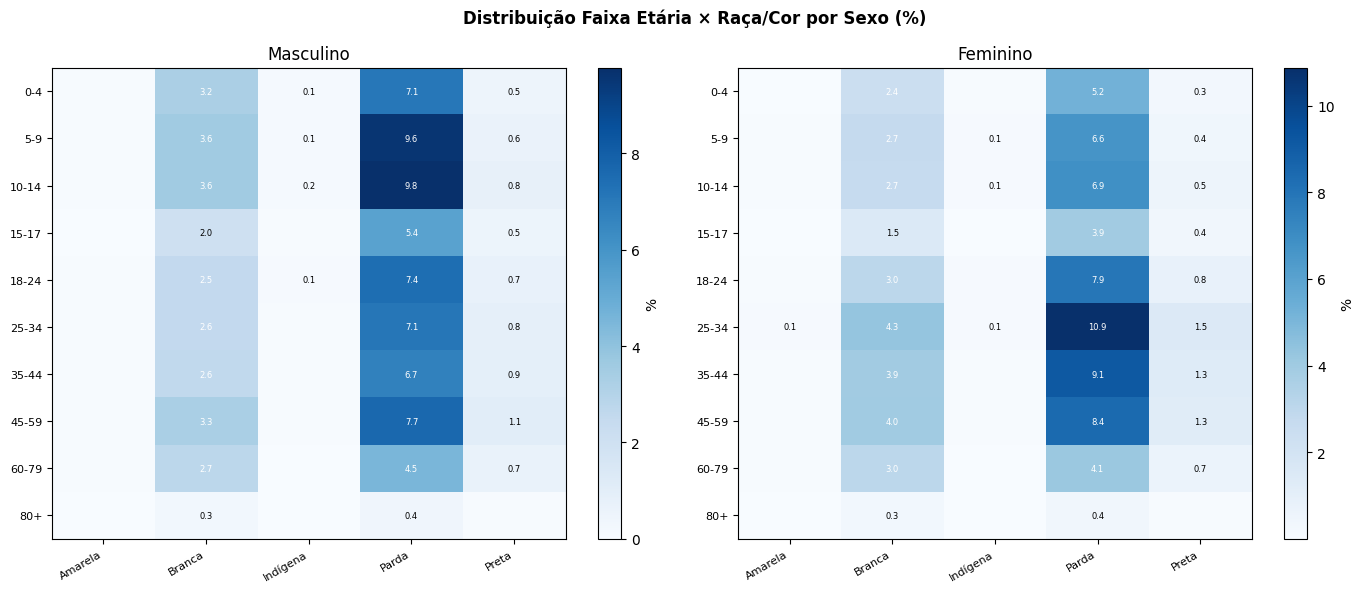

In [27]:
print("\n=== 9. Heatmap Faixa Etária × Raça por Sexo ===")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, sexo_label in zip(axes, ["Masculino", "Feminino"]):
    sub = df[df["sexo"] == sexo_label]
    pivot = sub.groupby(["faixa", "raca"], observed=True).size().unstack(fill_value=0)
    pivot_pct = pivot.div(pivot.sum().sum()).mul(100)

    im = ax.imshow(pivot_pct.values, cmap="Blues", aspect="auto")
    ax.set_xticks(range(len(pivot_pct.columns)))
    ax.set_xticklabels(pivot_pct.columns.tolist(), rotation=30, ha="right", fontsize=8)
    ax.set_yticks(range(len(pivot_pct.index)))
    ax.set_yticklabels(pivot_pct.index.tolist(), fontsize=8)
    ax.set_title(sexo_label)
    plt.colorbar(im, ax=ax, label="%")

    for i in range(pivot_pct.shape[0]):
        for j in range(pivot_pct.shape[1]):
            v = pivot_pct.iloc[i, j]
            if v > 0.1:
                ax.text(j, i, f"{v:.1f}", ha="center", va="center",
                        fontsize=6, color="white" if v > 2 else "black")

plt.suptitle("Distribuição Faixa Etária × Raça/Cor por Sexo (%)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## RESUMO TEXTUAL

In [28]:
print("\n" + "="*55)
print("RESUMO — Análise Aprofundada de Sexo")
print("="*55)
n_m = (df["sexo"] == "Masculino").sum()
n_f = (df["sexo"] == "Feminino").sum()
print(f"  Masculino : {n_m:,} ({n_m/len(df)*100:.1f}%)")
print(f"  Feminino  : {n_f:,} ({n_f/len(df)*100:.1f}%)")
print(f"\n  Idade média — Masculino: {df[df['sexo']=='Masculino']['idade'].mean():.1f} anos")
print(f"  Idade média — Feminino : {df[df['sexo']=='Feminino']['idade'].mean():.1f} anos")
print("Concluído.")


RESUMO — Análise Aprofundada de Sexo
  Masculino : 86,475 (43.2%)
  Feminino  : 113,525 (56.8%)

  Idade média — Masculino: 24.7 anos
  Idade média — Feminino : 28.3 anos
Concluído.
